In [1]:
library(tidyverse)
library(lubridate)
library(ggridges)
library(ComplexUpset)


source("../theme_ggplot_cfrna.R")
source("../functions.R")
gene_key = read.delim("../gencode.biotype.name.key.tsv")

── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

✔ ggplot2 3.5.1     ✔ purrr   1.0.2
✔ tibble  3.2.1     ✔ dplyr   1.1.4
✔ tidyr   1.3.1     ✔ stringr 1.5.1
✔ readr   2.1.2     ✔ forcats 0.5.1

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




---
# Counts

In [2]:
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    mutate(rel_trans = ymd(date) - ymd(transplant_date)) %>%
    filter(ORIGIN == "DFCI")

mdf %>% 
    filter(sample_group %in% c("COMP","REF")) %>% 
    nrow()

mdf %>% 
    filter(sample_group %in% c("COMP","REF")) %>% 
    pull(Record_ID) %>% unique() %>% 
    length()

[1] 449

[1] 96

---
## Figure 1 - ridge plot

In [7]:
### load metadata and timepoint data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% 
    mutate(rel_trans = ymd(date) - ymd(transplant_date)) %>%
    filter(ORIGIN == "DFCI")


## refactor and get date relative to PR
mdf <- mdf %>% 
    mutate(plot_esym = ifelse(timepoint %in% c("D1","D2","R1","R2","S2"),"Other",timepoint)) %>%
    mutate(plot_esym = factor(plot_esym, levels = rev(c("PR","D0","E","1M","2M","3M","6M","Other","IRB","HD"))))

## get date relative to PR
mdf <- mdf %>%
    mutate(day_rel_transplant = as.numeric(difftime(date, transplant_date, units = "days")))

# mdf %>% 
#     filter(is.na(day_rel_transplant)) %>%
#     select(sample_id, plot_esym, day_rel_transplant, date, transplant_date) 

In [9]:
print(table(mdf$plot_esym,useNA= "always"))
cat("total samples: ")
print(nrow(mdf))

mdf_tmp <- mdf %>% 
        mutate(YTIT = case_when(
                plot_esym == "PR" ~ "Pre-Conditioning",
                plot_esym == "D0" ~ "Day of Infusion",
                plot_esym == "E" ~ "Engraftment",
                plot_esym == "1M" ~ "1 Month Post-Infusion",
                plot_esym == "2M" ~ "2 Months Post-Infusion",
                plot_esym == "3M" ~ "3 Months Post-Infusion",
                plot_esym == "6M" ~ "6 Months Post-Infusion",
                plot_esym == "Other" ~ "Other - OT",
                plot_esym == "HD" ~ "Healthy Donor - HD"
        )) %>% 
        mutate(YTIT = factor(YTIT, levels = rev(c("Pre-Conditioning","Day of Infusion","Engraftment",
                                                "1 Month Post-Infusion",
                                                "2 Months Post-Infusion","3 Months Post-Infusion","6 Months Post-Infusion",
                                                "Other - OT","Healthy Donor - HD"))))

##-------------------------
## E -> 6M

plt <- mdf_tmp %>% filter(plot_esym %in% c("E","1M","2M","3M","6M","Other")) %>% 
        ggplot(aes(x = day_rel_transplant, y = YTIT, fill = plot_esym, height = stat(density))) +
        geom_density_ridges2(stat = "density", scale = 2, alpha = 0.5,size = 0.25)+ 
        theme_cfrna_print() + 
        labs(x = "Days Relative to Transplant", title = "Timing of Sample Collection After Transplantation")+
        # theme_ridges() + 
        theme(legend.position = "none", 
                plot.margin = unit(c(1,1,1,1), "pt"),
                plot.title = element_text(size = 8, hjust = 0.5, vjust = -2),
                axis.title.x = element_text(size = 6), 
                axis.title.y = element_blank(),
                axis.text.x = element_text(size = 6),
                axis.text.y = element_text(size = 6))+

        theme(  
                # panel.border = element_blank(),             # Remove all borders initially
                # axis.line = element_line(),                 # Add back the bottom and left lines
                # axis.line.x.top = element_blank(),          # Ensure top border is removed
                # axis.line.y.right = element_blank(),        # Ensure right border is removed
                panel.grid.minor = element_blank(),       # Remove minor gridlines
                panel.grid.major.x = element_blank()        # Remove major x gridlines
        )+
        scale_x_continuous(breaks = c(0,50,100,150,200,250),lim=c(0,250))+
        scale_fill_manual(values = c("E" = "#4477AA",   # Rich blue (Engraftment)
                                "1M" = "#EE7733",  # Vibrant orange (1M post)
                                "2M" = "#CC3311",  # Deep red (2M post)
                                "3M" = "#009988",  # Teal (3M post)
                                "6M" = "#882255")  # Dark magenta (6M post)
                                )

WIDTH= 3.39
HEIGHT= 1.6
pdf(file="figures/RIDGE_E-6M.pdf",
        width=WIDTH,height=HEIGHT, paper="special", bg="white",
        fonts="Helvetica", colormodel = "srgb", pointsize=6, useDingbats = FALSE)
print(plt)
dev.off()



   HD   IRB Other    6M    3M    2M    1M     E    D0    PR  <NA> 
   18    35     0    83    88    72    75    74    27    29     1 
total samples: [1] 502


png 
  2

In [7]:
mdf_tmp %>% filter(plot_esym == "E") %>% pull(rel_transplant) %>% summary()

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  10.00   16.00   19.00   18.85   21.00   25.00 

---
# COMP vs no COMP

In [7]:
library(rstatix)
library(ggpubr)


Attaching package: ‘rstatix’


The following object is masked from ‘package:stats’:

    filter




In [8]:
### load metadata and timepoint data
mdf = read.delim("../1_DATA/sample_meta_passQC.tsv") %>% filter(ORIGIN == "DFCI")

mdf = mdf %>% 
    mutate(timepoint = factor(timepoint, levels = EVENTS)) %>% filter(!is.na(timepoint)) %>% 
    mutate(timepoint_sym = factor(timepoint_sym, levels = EVENTS_sym)) %>% filter(!is.na(timepoint_sym)) %>% 
    mutate(HD = factor(HD, levels = c(1,0)))

mdf$timepoint = droplevels(mdf$timepoint)
mdf$timepoint_sym = droplevels(mdf$timepoint_sym)

### load metrics
metrics = read.delim("../1_DATA/metrics_passQC.tsv")

mdf = merge(mdf, metrics, by = "sample_id")

In [9]:
table(mdf$timepoint_sym, mdf$sample_group )

                  
                   COMP HD REF
  Healthy Donor       0 18   0
  Pre-Conditioning   26  0   3
  Day of Infusion    25  0   2
  Engraftment        65  0   9
  1 Month            67  0   8
  2 Month            63  0   9
  3 Month            79  0   9
  6 Month            73  0  10

Warning message in stat_compare_means(aes(group = sample_group, method = "wilcox.test", :
“Ignoring unknown aesthetics: method”


Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


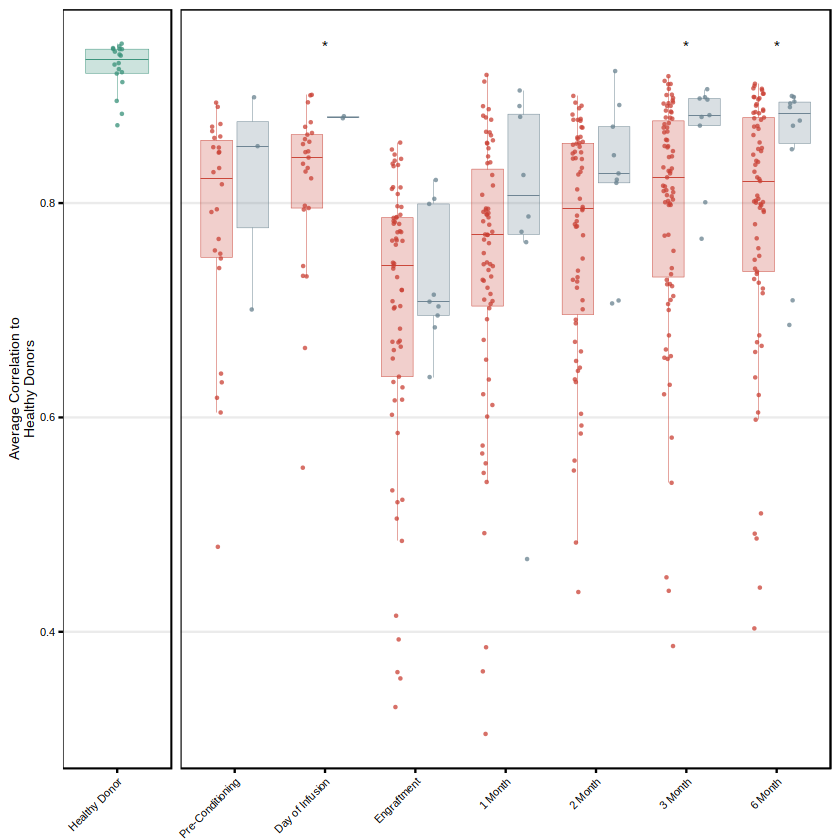

In [10]:
cor_plt = mdf %>%
  mutate(sample_group= factor(sample_group)) %>%
  ggplot(aes(x = timepoint_sym, y = avgCorrelation_trajectory, fill = sample_group, color = sample_group)) +

  geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

  geom_point(size = 1, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.3, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
  theme_cfrna_print() +
  theme(
      axis.title.x = element_blank(),
      axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
      panel.grid.major.x = element_blank(),        # Remove major x gridlines
    )+
  scale_fill_manual(values = COLORs)+
  scale_color_manual(values = COLORs)+
  theme(plot.title = element_text(size = 8, hjust = 0.5)) +
  facet_grid(~HD, scales = "free_x", space = "free") +
  labs(y = "Average Correlation to\nHealthy Donors")




cor_plt + stat_compare_means(
        aes(group = sample_group,method = "wilcox.test", label = after_stat(p.signif)),
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 3,
        vjust = .75,
        hide.ns = TRUE,
        )

WIDTH = 3.5
HEIGHT = 2.25
ggsave("./figures/COR_all.pdf",width=WIDTH, height = HEIGHT, units = "in")


In [45]:
cnts = mdf %>% group_by(Record_ID) %>% 
    summarise(n = n()) %>% 
    arrange(desc(n)) 

merge(mdf,cnts, by="Record_ID") %>% 
    filter(timepoint_sym == "6 Month") %>% 
    arrange(desc(avgCorrelation_trajectory)) %>% 
    arrange(avgCorrelation_trajectory) %>% 
    select(Record_ID, sample_group, n, avgCorrelation_trajectory) %>% 
     head(25)


,Record_ID,sample_group,n,avgCorrelation_trajectory
,<chr>,<chr>,<int>,<dbl>
1,100,COMP,5,0.4031769
2,42,COMP,5,0.4412241
3,72,COMP,5,0.4870373
4,56,COMP,5,0.4915525
5,14,COMP,6,0.5104733
6,27,COMP,7,0.5978949
7,93,COMP,5,0.6046252
8,92,COMP,7,0.6209158
9,13,COMP,8,0.6373333


In [35]:
mdf %>% filter(timepoint_sym == "6 Month") %>% arrange(desc(avgCorrelation_trajectory)) %>%  head(5)

,sample_id,Record_ID,date,timepoint,SCALE_qubit,sample_group,all_comps,transplant_date,date_taper_start,date_taper_end,⋯,leukocyte_decon,platelet_decon,rbc_decon,monocyte_decon,basophil_decon,G2M_Z,S_Z,repHistone_CPM,nonrepHistone_CPM,simpson
,<chr>,<chr>,<chr>,<fct>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,gvhd_hct_cfrna_549_bp61x61,91,2019-10-08,6M,5.122593e-09,COMP,_cgvhd_agvhd_bkvr,2019-04-23,NA,NA,⋯,0.06757269,0.8559101,8.639726e-20,8.985556e-20,8.514289e-20,-38.58919,-33.34793,4113.876,675.9278,0.2631361
2,gvhd_hct_cfrna_470_bp61x61,34,2019-04-11,6M,9.028117e-10,COMP,_relapse_cgvhd_bkvr,2018-10-02,NA,NA,⋯,0.23847227,0.5879917,2.939911e-03,4.383082e-02,9.066899e-20,-23.46062,-19.30469,5430.772,736.9687,0.6250341
3,gvhd_hct_cfrna_550_bp61x61,96,2019-12-05,6M,2.365112e-09,COMP,_relapse_bkvr,2019-06-12,NA,NA,⋯,0.27029398,0.5673695,8.748679e-20,1.531579e-10,7.506757e-05,-37.34180,-28.17053,3810.118,747.3678,0.6388837
4,gvhd_hct_cfrna_574_bp61x61,41,2019-05-01,6M,5.137126e-09,COMP,_cgvhd,2018-11-08,NA,NA,⋯,0.19427609,0.6521698,9.591841e-20,6.985779e-12,7.056874e-05,-40.68251,-33.85963,2631.983,527.6502,0.5541545
5,gvhd_hct_cfrna_541_bp61x61,75,2019-08-19,6M,2.772013e-09,COMP,_cgvhd,2019-02-27,NA,NA,⋯,0.09319376,0.8068886,6.013591e-04,8.500917e-20,8.682202e-20,-41.51877,-35.96419,4124.805,587.1896,0.3418896


In [23]:
mdf = mdf %>% mutate(event_sym = timepoint)
mdf = mdf %>% mutate(event_sym = factor(event_sym, levels = EVENTS)) %>% filter(!is.na(event_sym))
mdf$event_sym  = droplevels(mdf$event_sym)

### read in counts of top 500 most variable
counts_sub <- read.delim("../1_DATA/counts_sQC_gTop500mv_nVST.tsv")[,mdf$sample_id]

In [24]:
### get sample groups
COMP_sids = mdf %>% filter(sample_group == "COMP") %>% pull(sample_id)
REF_ids = mdf %>% filter(sample_group == "REF") %>% pull(sample_id) 
HD_ids = mdf %>% filter(sample_group == "HD") %>% pull(sample_id)

### Correlation to COMPs
comp_cor <- get_avg_cor(counts_sub,
                        COMP_sids,
                        mdf ,
                        ref_group = "ES_REF",
                        cor_method = "pearson") %>% 
                rename(cor_to_comp = avg_cor_ref)


### Correlation to REFs
ref_cor <- get_avg_cor(counts_sub,
                        REF_ids,
                        mdf ,
                        ref_group = "ES_REF",
                        cor_method = "pearson") %>% 
                rename(cor_to_ref = avg_cor_ref)

### Correlation to HDs
hd_cor <- get_avg_cor(counts_sub,
                        HD_ids,
                        mdf ,
                        ref_group = "ES_REF",
                        cor_method = "pearson") %>% 
                rename(cor_to_hd = avg_cor_ref)


In [25]:
### Combine
all_cor <- merge(hd_cor, merge(comp_cor, ref_cor, by = "sample_id"), by = "sample_id") %>% 
    mutate(self = ifelse(sample_id %in% COMP_sids, cor_to_comp, cor_to_ref)) %>%
    mutate(other = ifelse(sample_id %in% COMP_sids, cor_to_ref, cor_to_comp)) %>% 
    mutate(self = ifelse(sample_id %in% HD_ids, cor_to_hd, self)) %>%
    select(sample_id, self, other) %>%
    reshape2::melt(id.vars = c("sample_id"), variable.name = "cor_group", value.name = "cor")

meta_cor <- merge(mdf %>% select(sample_id, event_sym, sample_group, timepoint_sym, HD),all_cor, by="sample_id") %>% 
    mutate(GRP = paste0(sample_group,"_",cor_group)) %>% unique()

meta_cor %>% head()

,sample_id,event_sym,sample_group,timepoint_sym,HD,cor_group,cor,GRP
,<chr>,<fct>,<chr>,<fct>,<fct>,<fct>,<dbl>,<chr>
1,gvhd_hct_cfrna_1_bp51x51,2M,REF,2 Month,0,self,0.7863343,REF_self
2,gvhd_hct_cfrna_1_bp51x51,2M,REF,2 Month,0,other,0.7557301,REF_other
3,gvhd_hct_cfrna_100_bp61x61,2M,COMP,2 Month,0,self,0.8118765,COMP_self
4,gvhd_hct_cfrna_100_bp61x61,2M,COMP,2 Month,0,other,0.7769764,COMP_other
5,gvhd_hct_cfrna_101_bp61x61,2M,COMP,2 Month,0,other,0.8487284,COMP_other
6,gvhd_hct_cfrna_101_bp61x61,2M,COMP,2 Month,0,self,0.8306561,COMP_self


Warning message in stat_compare_means(aes(group = sample_group, method = "wilcox.test", :
“Ignoring unknown aesthetics: method”


Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”
Warning message:
“Unknown or uninitialised column: `p`.”
Warning message:
“Computation failed in `stat_compare_means()`.
Caused by error:
! argument "x" is missing, with no default”


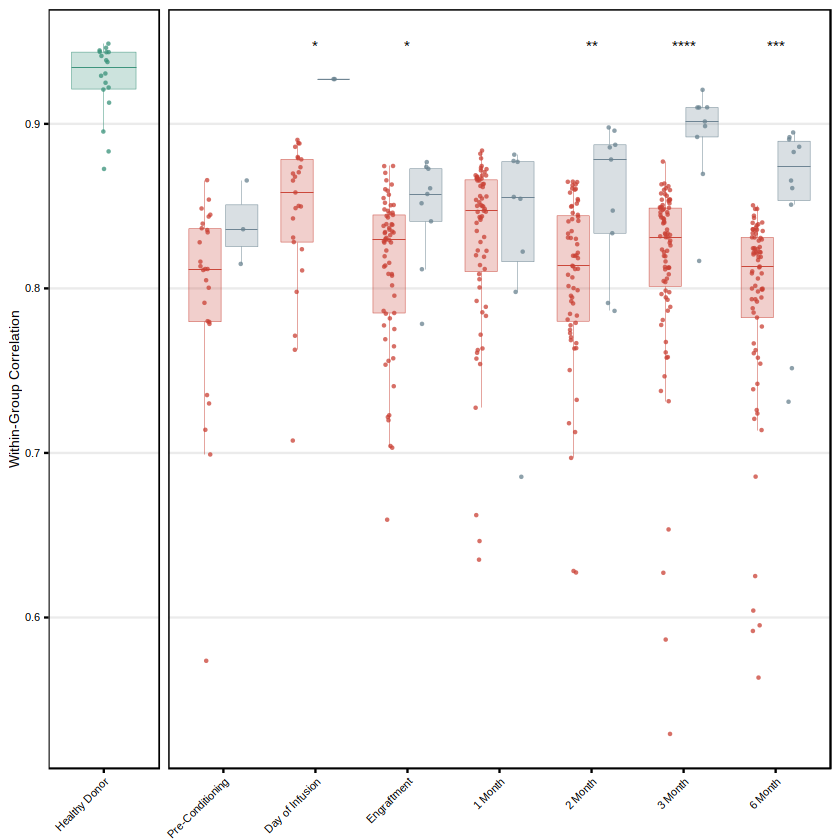

In [26]:
plt_responders <- meta_cor %>% 
    mutate(GRP = factor(GRP, levels = rev(c("HD_self", "REF_self","COMP_self")))) %>%
    filter(!is.na(GRP)) %>% 
    ggplot(aes(x=timepoint_sym, y=cor, color = GRP, fill=GRP))+
    geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.25, size = 0.1) +

     geom_point(size = 1, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.3, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
    theme_cfrna_print() +
    labs(y="Within-Group Correlation")+
    theme(
        axis.title.x = element_blank(),
        axis.text.x = element_text(size = 6, angle = 45, hjust = 1),
        legend.position = "none",
        # panel.border = element_blank(),             # Remove all borders initially
        # axis.line = element_line(),                 # Add back the bottom and left lines
        # axis.line.x.top = element_blank(),          # Ensure top border is removed
        # axis.line.y.right = element_blank(),        # Ensure right border is removed
        panel.grid.minor.y = element_blank(),       # Remove minor gridlines
        panel.grid.major.x = element_blank(),        # Remove major x gridlines
        strip.text = element_blank(),
            strip.background = element_blank()
        )+
        facet_grid(~HD, scales = "free_x", space = "free") +
        scale_color_manual(values = c("REF_self" = COLORs[["REF"]], 
                                        "COMP_self" = COLORs[["COMP"]],
                                        "HD_self" = COLORs[["HD"]]))+
        scale_fill_manual(values = c("REF_self" = COLORs[["REF"]], 
                                        "COMP_self" = COLORs[["COMP"]],
                                        "HD_self" = COLORs[["HD"]]))+
        facet_grid(~HD, scales = "free_x", space = "free") 
        
plt_responders  + stat_compare_means(
        aes(group = sample_group,method = "wilcox.test", label = after_stat(p.signif)),
        symnum.args = list(cutpoints = c(0, 0.0001, 0.001, 0.01, 0.1, Inf), symbols = c("****", "***", "**", "*", "ns")),
        size = 3,
        vjust = .75,
        hide.ns = TRUE,
        )


WIDTH = 3.5
HEIGHT = 2.25
ggsave("./figures/AK_all.pdf",width=WIDTH, height = HEIGHT, units = "in")
